<h3>LIBRERIAS</h3>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

<h3>CARGAR</h3>

In [2]:
ruta = Path(r"../1. Datasets/2. Dataset Limpio")

df = pd.read_parquet(ruta/"sleep_disruption.parquet")

In [3]:
df.head()

,id_usuario,anio,pais,grupo_edad,genero,plataforma,promedio_horas_sueno,puntaje_calidad_sueno,horas_uso_nocturno,nivel_fatiga,clasificacion_sueno,fatiga_categoria
0,16429,2060,Canada,Young Adult,Male,Twitch,6.65,82.07,4.43,27.18,Aceptable,Leve
1,8126,2041,Saudi Arabia,Senior,Male,Facebook,4.86,58.04,5.30,80.17,Insuficiente,Severa
2,3247,2023,Japan,Teen,Male,Snapchat,6.04,67.19,2.69,4.87,Aceptable,Leve
3,15986,2040,Italy,Senior,Female,X/Twitter,6.87,64.08,1.44,10.65,Aceptable,Leve
4,2914,2057,South Korea,Teen,Male,YouTube,6.16,61.54,1.26,1.83,Aceptable,Leve


In [3]:
df = df[df['anio'].between(2010, 2025)]

df

,id_usuario,anio,pais,grupo_edad,genero,plataforma,promedio_horas_sueno,puntaje_calidad_sueno,horas_uso_nocturno,nivel_fatiga
2,3247,2023,Japan,Teen,Male,Snapchat,6.04,67.19,2.69,4.87
8,3174,2023,Canada,Teen,Other,Snapchat,8.55,92.93,0.13,3.70
12,18661,2015,Japan,Young Adult,Male,Instagram,6.07,44.64,2.78,9.96
14,3571,2020,Canada,Young Adult,Other,Discord,7.99,56.61,4.74,3.77
16,8639,2010,South Korea,Children,Other,X/Twitter,4.26,48.97,3.15,17.11
...,...,...,...,...,...,...,...,...,...,...
49991,3278,2018,South Korea,Senior,Other,Snapchat,10.13,37.68,3.09,66.77
49996,23658,2024,Germany,Teen,Other,LinkedIn,7.11,71.28,1.66,38.84
49997,13660,2025,Australia,Senior,Female,TikTok,6.45,49.97,2.56,19.45
49998,14089,2015,Saudi Arabia,Teen,Other,Instagram,7.48,54.52,3.94,99.57


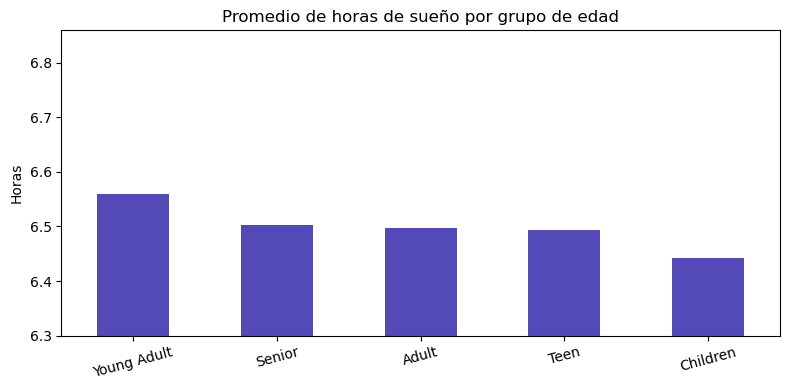

In [6]:
# 1. HORAS DE SUEÑO POR GRUPO DE EDAD 
edad_sueno = df.groupby('grupo_edad')['promedio_horas_sueno'].mean().sort_values(ascending=False)
edad_sueno.plot(kind='bar', figsize=(8, 4), color='#534AB7')
plt.title('Promedio de horas de sueño por grupo de edad')
plt.ylabel('Horas')
plt.ylim(6.3, edad_sueno.max() + 0.3)
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

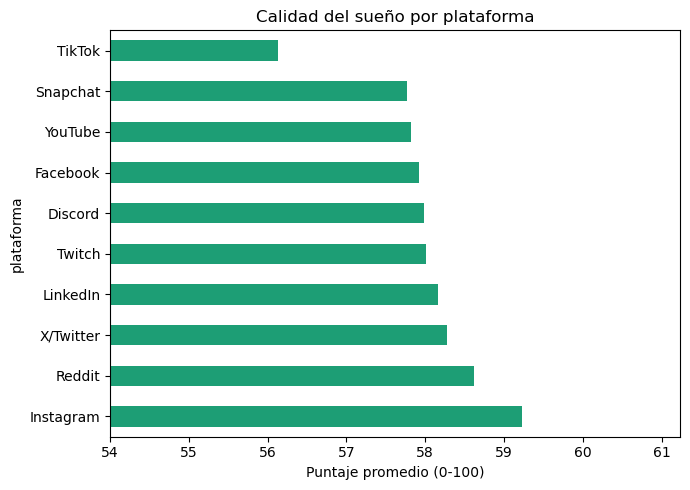

In [7]:
# 2. CALIDAD DEL SUEÑO POR PLATAFORMA 
plat_calidad = df.groupby('plataforma')['puntaje_calidad_sueno'].mean().sort_values(ascending=False)
plat_calidad.plot(kind='barh', figsize=(7, 5), color='#1D9E75')
plt.title('Calidad del sueño por plataforma')
plt.xlabel('Puntaje promedio (0-100)')
plt.xlim(54, plat_calidad.max() + 2)
plt.tight_layout()
plt.show()

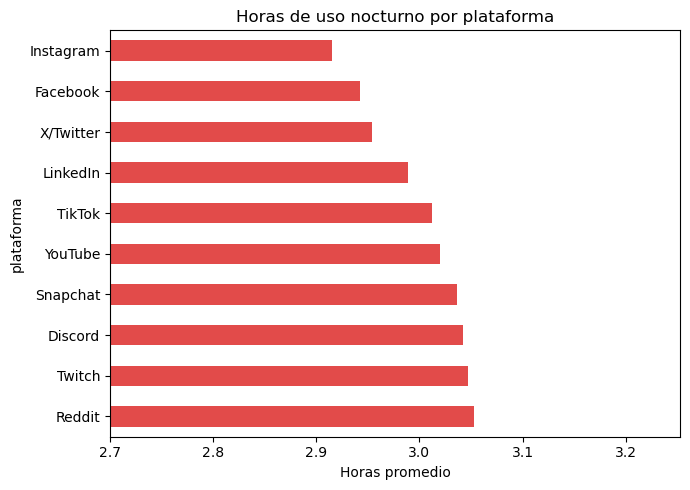

In [9]:
# 3. USO NOCTURNO POR PLATAFORMA 
plat_nocturno = df.groupby('plataforma')['horas_uso_nocturno'].mean().sort_values(ascending=False)
plat_nocturno.plot(kind='barh', figsize=(7, 5), color='#E24B4A')
plt.title('Horas de uso nocturno por plataforma')
plt.xlabel('Horas promedio')
plt.xlim(2.7, plat_nocturno.max() + 0.2)
plt.tight_layout()
plt.show()

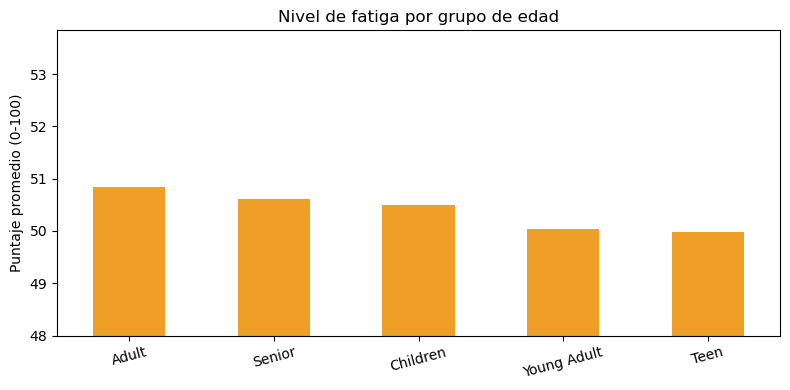

In [11]:
# 4. NIVEL DE FATIGA POR GRUPO DE EDAD 
edad_fatiga = df.groupby('grupo_edad')['nivel_fatiga'].mean().sort_values(ascending=False)
edad_fatiga.plot(kind='bar', figsize=(8, 4), color='#EF9F27')
plt.title('Nivel de fatiga por grupo de edad')
plt.ylabel('Puntaje promedio (0-100)')
plt.ylim(48, edad_fatiga.max() + 3)
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

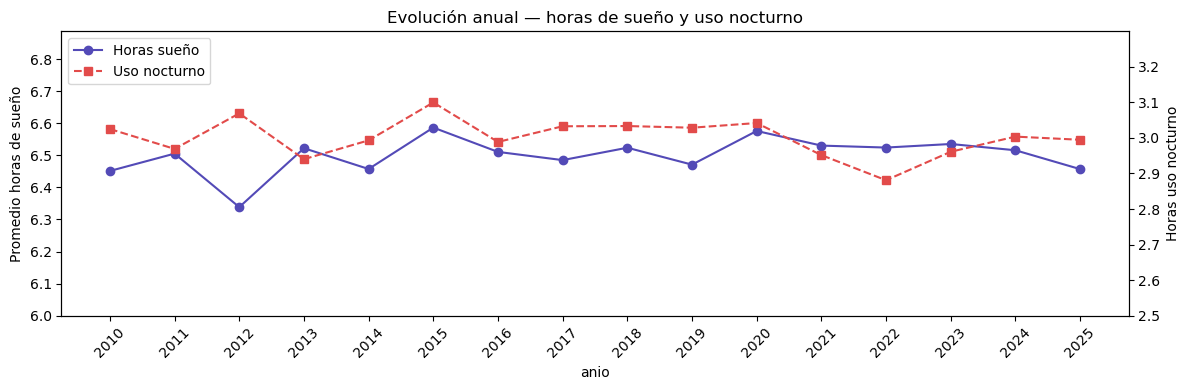

In [12]:
# --- 5. EVOLUCIÓN ANUAL ---
anio_scores = df.groupby('anio')[['promedio_horas_sueno', 'horas_uso_nocturno']].mean()
fig, ax = plt.subplots(figsize=(12, 4))
anio_scores['promedio_horas_sueno'].plot(ax=ax, marker='o', color='#534AB7', label='Horas sueño')
ax2 = ax.twinx()
anio_scores['horas_uso_nocturno'].plot(ax=ax2, marker='s', color='#E24B4A', label='Uso nocturno', linestyle='--')
ax.set_title('Evolución anual — horas de sueño y uso nocturno')
ax.set_ylabel('Promedio horas de sueño')
ax2.set_ylabel('Horas uso nocturno')
ax.set_ylim(6.0, anio_scores['promedio_horas_sueno'].max() + 0.3)
ax2.set_ylim(2.5, anio_scores['horas_uso_nocturno'].max() + 0.2)
ax.set_xticks(anio_scores.index)
ax.tick_params(axis='x', rotation=45)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

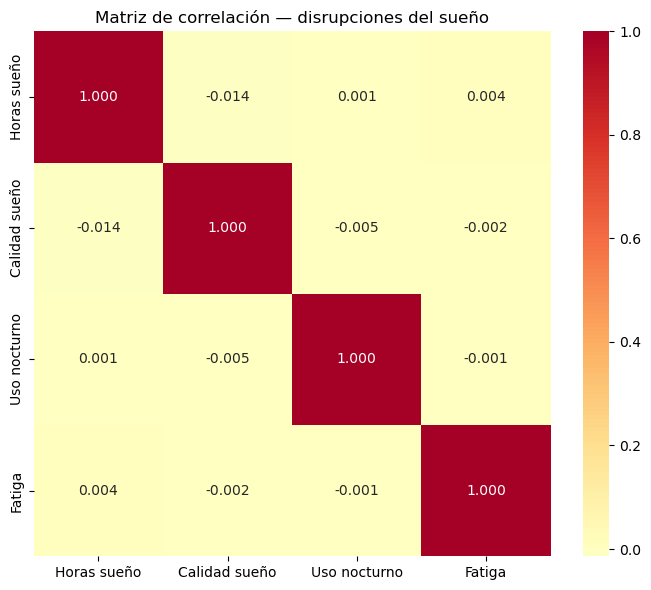

In [14]:
# 6. MATRIZ DE CORRELACIÓN 
cols_num = ['promedio_horas_sueno', 'puntaje_calidad_sueno',
            'horas_uso_nocturno', 'nivel_fatiga']
corr = df[cols_num].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            xticklabels=['Horas sueño', 'Calidad sueño', 'Uso nocturno', 'Fatiga'],
            yticklabels=['Horas sueño', 'Calidad sueño', 'Uso nocturno', 'Fatiga'],
            ax=ax)
ax.set_title('Matriz de correlación — disrupciones del sueño')
plt.tight_layout()
plt.savefig('7_correlacion.png', dpi=150)
plt.show()

In [ ]:
ruta2 = Path(r"../1. Datasets/3. Dataset Final")

df = pd.read_parquet(ruta/"sleep_disruption.parquet")